# Data analysis

This notebook assumes the previous execution of the `scripts/prepare_pcap.py` script to generate a CSV from the raw PCAP file. This script will generate a CSV from the input file and perform flow tracking. On a AMD Ryzen 5700U, the script takes ~15min. It is possible to truncate the result by taking a limited amount of packets:

```sh
python scritps/prepare_pcap.py -c 10000 <path-to-pcap>
```

## Introduction
The notebook is structured as follows:

- Packet level analysis:
  + Packet size: fit with bimodal distribution
- Flow level analysis (focused on TCP):
  + Flow duration

In [13]:
import pandas as pd
    
fname = "dataset/201302011400-10000.csv"

df = pd.read_csv(fname)

df.head()

,Unnamed: 0,frame.number,frame.time_relative,frame.time_delta,frame.len,ip.src,ip.dst,ip.proto,port.src,port.dst,flow_id
0,0,1,0.000000,NaN,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
1,1,2,0.000003,0.000003,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
2,2,3,0.000006,0.000003,1514,200.11.79.20,140.198.115.132,6.0,80,52021,0
3,3,4,0.000009,0.000003,94,167.180.134.255,32.218.92.255,1.0,0,0,1
4,4,5,0.000012,0.000003,66,55.146.64.212,211.83.168.117,6.0,49191,3389,2


## Packet size analysis

First, we extract the packet_size from the `frame.len` field of the initial dataset.

Looking at the distribution plotted, it could be fit with the **bimodal** distribution. This can be explained as follows:

- **left peak**: small size packet usually used control traffic (handshake, acks)
- **right peak**: `~1500` bytes packets. Most OS tend to use all availble MTU for frames

The bimodal distribution is the sum of 2 gaussian. We need to estimate $\mu_1, \sigma_1, A_1$ and $\mu_2, \sigma_2, A_2$. This can be done by looking at data we have and using `curve_fit` from the `scipy.optimize` module. To speed up, we can tell the optimizer an initial guess. We know the left peak and right peak *x* position, so we can use them.

### Amplitude estimation
To get the Gaussian $A_1, A_2$, I simply partitioned the initial histogram and looked for the max values in the left zone and right zone. This is performed by looking at data and understanding the distribution initially.

## Goodness of fit
To evaluate the goodness of fit, I calculate the $R^2$ and $RMSE$ using the functions provided below.

\begin{equation}
    R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
\end{equation}

$\overline{y}$ is the mean of the initial dataset. $y_i$ is a point of the initial dataset. $f_{i}$ is a point of the fitted distribution. 

$SS_{res}$ is the sum of square of residual. It indicates how much data fitted in the model differs from the mean value of original data (we take always the sum of squares to remove negative values).
\begin{equation}
    SS_{res} = \sum_{i=1}^n (y_i - f_i)^2
\end{equation}

$SS_{tot}$ is the total sum of squares. It is obtained with the difference between $y_i$ and $\overline{y}$
\begin{equation}
    SST = \sum_{i=1}^n (y_i - \overline{y})^2
\end{equation}

$RMSE$ is the mean distance between predicted data and original data squared:

\begin{equation}
       RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - f_i)^2}
\end{equation}

$0 \leq R^2 \geq 1$. A high $R^2$ tells we have a good fit. On the other hand, a low $RMSE$ tells we have a good fit. $RMSE$ is an easy to calculate factor, but it is sensitive when dealing outliers.

## Results
In this case, $R^2 > 0.9$ so the the `curve_fit` parameter is a good approximation of the initial dataset.

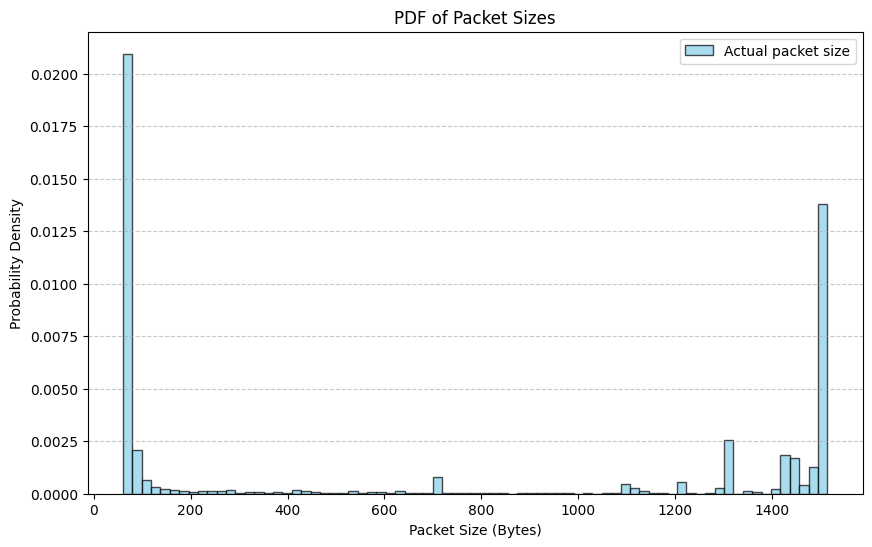

0    1514
1    1514
2    1514
3      94
4      66
Name: frame.len, dtype: int64
Estimated params: [6.94216333e+01 9.13334079e+00 2.09473865e-02 1.50454692e+03
 8.96936209e+00 1.38084146e-02]
R-squared: 0.9754275686185544
RMSE: 0.00044886116288780876


<Figure size 640x480 with 0 Axes>

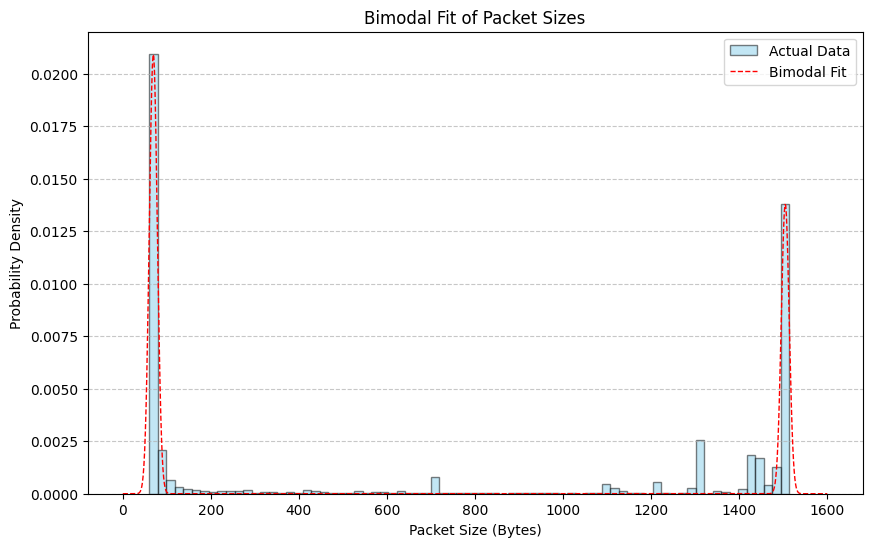

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def rsquared_rmse(predicted_data: np.ndarray, observed_data: np.ndarray) -> float:
    residuals = observed_data - predicted_data
    
    sse = np.sum(residuals ** 2)
    
    sst = np.sum((observed_data - np.mean(observed_data)) ** 2)

    r_squared = 1 - (sse / sst) 
    rmse = np.sqrt(np.mean(residuals**2))
    
    return r_squared, rmse 

# Create the bimodal from the sum of 2 gaussian
def gauss(x,mu,sigma,A):
    return A * np.exp(-(x-mu)**2/2 /sigma**2)

def bimodal(x,mu1,sigma1,A1,mu2,sigma2,A2):
    return gauss(x,mu1,sigma1,A1) + gauss(x,mu2,sigma2,A2)

bins = 75

packet_sizes = df["frame.len"].dropna()

pdf = plt.figure(figsize=(10, 6))

plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7, label="Actual packet size")
plt.title('PDF of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(packet_sizes.head())
# Save the single pdf for reference.
plt.savefig("figures/pdf-packet_size.pdf")
plt.close(pdf)

# Create a histogram to get the (x, y) coordinates for fitting
counts, bin_edges = np.histogram(packet_sizes, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Search for Amplitude parameter of the 2 gaussian. LLM helped here
left_zone = bin_centers < 500
peak1_center = bin_centers[left_zone][np.argmax(counts[left_zone])]
peak1_height = np.max(counts[left_zone])

right_zone = bin_centers > 1000
peak2_center = bin_centers[right_zone][np.argmax(counts[right_zone])]
peak2_height = np.max(counts[right_zone])

# Initial guess: needed because curve_fit will give "Parameters not found error"
initial_guess = [peak1_center, 10, peak1_height, peak2_center, 10, peak2_height]

# Specify bound to avoid useless search, constrain to both peaks
lower_bounds = [0,   1,   0,                  1000, 1,   0]          
upper_bounds = [500, 200, peak1_height, 1600, 200, peak2_height] 

# Find optimal parameters
params, cov = curve_fit(
    bimodal, 
    bin_centers, 
    counts, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds),
    maxfev=10000
)

plt.figure(figsize=(10,6))
# Plot origial data
plt.hist(packet_sizes, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.5, label="Actual Data")

# Plot the bimodal-distribution
x_range = np.linspace(0, 1600, 1000)
plt.plot(x_range, bimodal(x_range, *params), color='red', linestyle="--", lw=1, label='Bimodal Fit')

plt.title('Bimodal Fit of Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("Estimated params:", params)
plt.savefig("figures/bimodalfit-packet-size.pdf")

# Goodness of fit evaluation
y_predicted = bimodal(bin_centers, *params)
y_actual = counts

r_squared, rmse = rsquared_rmse(y_predicted, y_actual)
print("R-squared:", r_squared)
print("RMSE:", rmse)

# Flow analysis
In this section, I perform an analysis at flow level. First, I focus the flow duration.

## Feature extraction
Leveraging, the results from `scripts/prepare_pcap.py`, we can simply aggregate metrics per flow by using the `groupy` method. As in the code, we extract 3 feature and save them in `flow_stats` data frame:

- duration: duration of the flow (from the first to the last packet timestamp registered);
- total bytes: sum of bytes sent over the flow;
- packet count: total number of packets;
- throughput: total bytes sent during the whole communication;

## Plotting flow durations

In [21]:
# Compute duration, total bytes and packet count
flow_stats = df.groupby('flow_id').agg(
    duration=('frame.time_relative', lambda x: x.max() - x.min()),
    total_bytes=('frame.len', 'sum'),
    packet_count=('frame.number', 'count')
)

flow_stats['throughput'] = flow_stats['total_bytes'] / flow_stats['duration'].replace(0, 1)

flow_stats.head()

,duration,total_bytes,packet_count,throughput
flow_id,,,,
0,0.001511,40878,27,2.705361e+07
1,0.000000,94,1,9.400000e+01
2,0.290324,7318,116,2.520632e+04
3,0.190752,792,12,4.151988e+03
4,0.000000,66,1,6.600000e+01


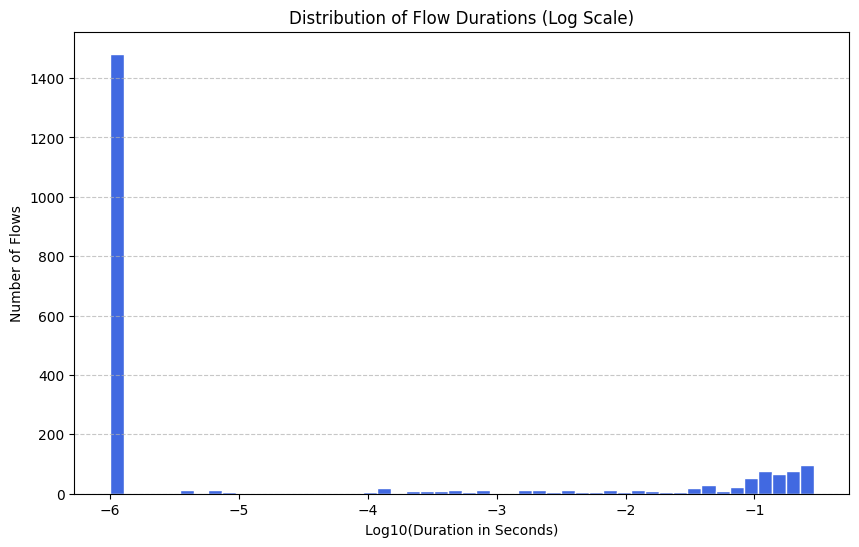

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Add offset to avoid log10(0)
log_durations = np.log10(flow_stats['duration'] + 1e-6)

# Pure matplotlib histogram
plt.hist(log_durations, bins=50, color='royalblue', edgecolor='white')

plt.title('Distribution of Flow Durations (Log Scale)')
plt.xlabel('Log10(Duration in Seconds)')
plt.ylabel('Number of Flows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

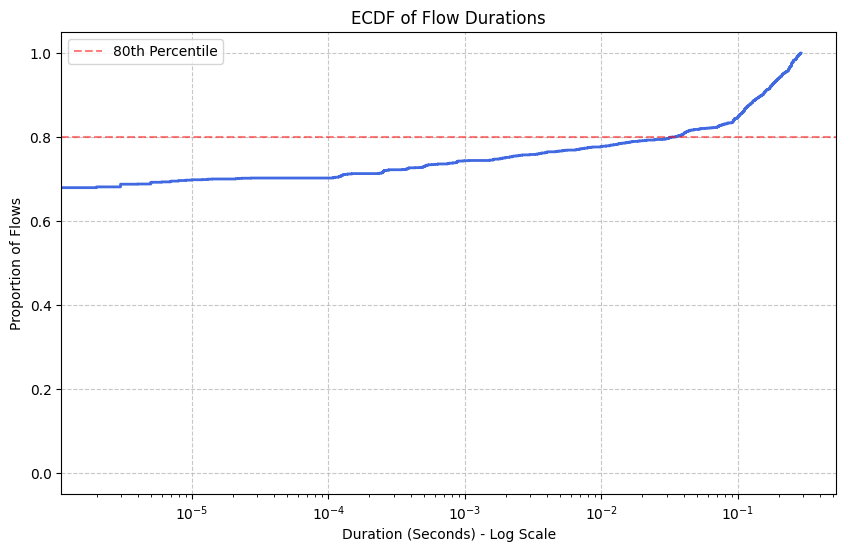

In [17]:
plt.figure(figsize=(10, 6))

# 1. Sort the durations
x = np.sort(flow_stats['duration'])

# 2. Calculate the cumulative probability for each point
y = np.arange(1, len(x) + 1) / len(x)

# 3. Plot as a step function
plt.step(x, y, where='post', color='royalblue', linewidth=2)

# Set the x-axis to a logarithmic scale
plt.xscale('log')

plt.title('ECDF of Flow Durations')
plt.xlabel('Duration (Seconds) - Log Scale')
plt.ylabel('Proportion of Flows')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='80th Percentile')
plt.legend()
plt.show()

In [20]:
# Compute IAT per flow
df["flow_iat"] = df.groupby("flow_id")["frame.time_relative"].diff()

# Compute packet_counts and IAT stats
flow_iat_stats = df.groupby('flow_id').agg(
    packet_count=('frame.number', 'count'),
    mean_iat=('flow_iat', 'mean'),
    max_iat=('flow_iat', 'max'),
    jitter=('flow_iat', 'std') # Standard Deviation of IAT is Jitter
).dropna()
flow_iat_stats.head()

,packet_count,mean_iat,max_iat,jitter
flow_id,,,,
0,27,0.000058,0.000846,0.000167
2,116,0.002525,0.025737,0.003813
3,12,0.017341,0.076821,0.024543
6,44,0.004793,0.096447,0.017750
9,13,0.008651,0.028863,0.009813
